# 📈 Machine Learning — PP2: Regressão Baseada em Resíduos
> **Projeto Brasil em Foco | PISI 3 — UFRPE 2026.1**


- 👥 **Autores:** Arthur Barbosa, Danielly Nunes, Gabriel Sabino, Isadora Morais, Luiz Vinícius
- 🔗 **Repositório:** [github.com/IsadoraMoraiss/Project_Pisi3](https://github.com/IsadoraMoraiss/Project_Pisi3.git)
- 🗂️ **Dataset:** [Brazilian Cities — Kaggle](https://www.kaggle.com/datasets/crisparada/brazilian-cities)
- 📚 **Metodologia:** KDD (Knowledge Discovery in Databases)


## 🎯 Pergunta de Negócio

> *"Dado o perfil socioeconômico de um município (PIB, população, densidade e região),  
> qual seria o seu nível esperado de absorção turística (leitos por mil habitantes)?  
> E onde o real fica muito abaixo do esperado?"*

Municípios com **resíduo muito negativo** (modelo previu muito mais do que a realidade)  
são as **Joias Ocultas** — alto potencial socioeconômico, baixo aproveitamento turístico.



## 🗺️ Fluxo KDD

| Fase KDD | Seção |
|---|---|
| Seleção & Pré-processamento | 1–3 |
| Transformação (Pipeline) | 3 |
| Mineração (Treinamento + GridSearch) | 4 |
| Avaliação (R², MAE, RMSE + Overfitting) | 5 |
| Conhecimento (Resíduos + Joias Ocultas) | 6 |
| Exportação do Campeão | 7 |


---
## ⚙️ Seção 1 — Configuração do Ambiente e Definição da SEED

`SEED = 42` é fixada em **todos** os pontos de aleatoriedade para garantir
**reprodutibilidade estrita**: os resultados serão idênticos a cada execução.


In [ ]:
# ── Bibliotecas gerais ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import joblib
import os

# ── Scikit-Learn: Pré-processamento ──────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── Scikit-Learn: Modelos de Regressão ────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# ── Scikit-Learn: Validação e Métricas ───────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    KFold,                   # KFold tradicional — target contínuo não precisa de estratificação
    RepeatedKFold,           # alternativa mais robusta
    cross_validate,
    GridSearchCV,
)
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    make_scorer,
)

# ── Configurações globais ─────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
np.random.seed(42)

# ── SEED ÚNICA E DOCUMENTADA ──────────────────────────────────────────────────
# Utilizada em: train_test_split, KFold, RandomForestRegressor,
#               GradientBoostingRegressor, GridSearchCV.
SEED = 42

print(f'✅ Ambiente configurado | SEED = {SEED}')
import sklearn
print(f'   pandas  {pd.__version__} | numpy {np.__version__} | sklearn {sklearn.__version__}')

✅ Ambiente configurado | SEED = 42
   pandas  2.2.2 | numpy 2.0.2 | sklearn 1.6.1


---
## 📥 Seção 2 — Carregamento dos Dados (KDD — Seleção)

### Anti-circularidade e Anti-colinearidade

```
Features (X)                        Target (y)
─────────────────────────────────   ─────────────────────────────────────
PIB_per_capita  (IBGE/RAIS)         Leitos_por_Mil_Hab  (IBGE/RAIS/CADASTUR)
Populacao       (IBGE)              → Proxy de absorção turística estrutural
Densidade       (IBGE)              → Calculado como BEDS / IBGE_RES_POP × 1.000
Regiao          (IBGE)
─────────────────────────────────
❌ IDHM removido — alta correlação com PIB (multicolinearidade)
```

O dataset aceita **dois modos**:
- **Modo Real**: carrega o CSV do disco / Google Drive.
- **Modo Mock**: gera 300 municípios simulados automaticamente (fallback).


In [ ]:
# ── Tentar carregar o dataset real ────────────────────────────────────────────
# No Google Colab:
# from google.colab import drive; drive.mount('/content/drive')
# CSV_PATH = '/content/drive/MyDrive/BRAZIL_CITIES.csv'

CSV_PATH = 'BRAZIL_CITIES.csv'
MODO_REAL = False

if os.path.exists(CSV_PATH):
    df_raw = pd.read_csv(CSV_PATH, sep=';', encoding='latin-1', decimal=',')

    # Padronizar colunas (mesmo padrão da EDA e Clusterização)
    df_raw.columns = (
        df_raw.columns
        .str.lower().str.strip()
        .str.replace(' ', '_', regex=False)
        .str.replace(r'[^a-z0-9_]', '', regex=True)
    )

    # Mapeamento UF → Macrorregião
    map_regiao = {
        'AC':'Norte','AM':'Norte','AP':'Norte','PA':'Norte',
        'RO':'Norte','RR':'Norte','TO':'Norte',
        'AL':'Nordeste','BA':'Nordeste','CE':'Nordeste','MA':'Nordeste',
        'PB':'Nordeste','PE':'Nordeste','PI':'Nordeste','RN':'Nordeste','SE':'Nordeste',
        'DF':'Centro-Oeste','GO':'Centro-Oeste','MS':'Centro-Oeste','MT':'Centro-Oeste',
        'ES':'Sudeste','MG':'Sudeste','RJ':'Sudeste','SP':'Sudeste',
        'PR':'Sul','RS':'Sul','SC':'Sul',
    }

    # Converter e selecionar colunas
    for col in ['gdp_capita', 'ibge_res_pop', 'beds', 'estimated_pop', 'area']:
        if col in df_raw.columns:
            df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

    # Calcular target: Leitos por 1.000 habitantes
    if 'beds' in df_raw.columns and 'ibge_res_pop' in df_raw.columns:
        df_raw['Leitos_por_Mil_Hab'] = (
            df_raw['beds'] / (df_raw['ibge_res_pop'] + 1) * 1000
        )

    # Calcular densidade se não existir
    if 'area' in df_raw.columns and 'ibge_res_pop' in df_raw.columns:
        df_raw['Densidade'] = df_raw['ibge_res_pop'] / (df_raw['area'] + 1)
    else:
        df_raw['Densidade'] = np.nan

    df_raw['Regiao'] = df_raw['state'].map(map_regiao)

    # Renomear para nomenclatura padronizada do projeto
    df_raw = df_raw.rename(columns={
        'gdp_capita':    'PIB_per_capita',
        'ibge_res_pop':  'Populacao',
    })

    df_raw = df_raw[['PIB_per_capita','Populacao','Densidade',
                      'Regiao','Leitos_por_Mil_Hab']].dropna(
        subset=['PIB_per_capita','Populacao','Leitos_por_Mil_Hab']
    )

    MODO_REAL = True
    print(f'✅ Dataset REAL carregado: {df_raw.shape[0]} municípios')
    print(f'   Target — Leitos_por_Mil_Hab:  média={df_raw["Leitos_por_Mil_Hab"].mean():.2f}'
          f'  mediana={df_raw["Leitos_por_Mil_Hab"].median():.2f}'
          f'  max={df_raw["Leitos_por_Mil_Hab"].max():.2f}')
else:
    print('⚠️  CSV não encontrado — ativando MODO MOCK (dados simulados).')
    MODO_REAL = False

✅ Dataset REAL carregado: 887 municípios
   Target — Leitos_por_Mil_Hab:  média=6.98  mediana=2.43  max=710.53


### 2.1 Mock Data — Simulação Realista

**Target simulado (`Leitos_por_Mil_Hab`)**: log-normal assimétrica,
espelhando a concentração real do turismo brasileiro (maioria das cidades
tem muito poucos leitos; poucos destinos consolidados têm muitos).

**Correlação sintética introduzida**: cidades com maior PIB tendem a
ter mais leitos, mas com muito ruído — simulando o padrão real de
que estrutura econômica explica *parte* do turismo, não tudo.


In [ ]:
if not MODO_REAL:
    np.random.seed(SEED)
    N = 300

    regioes  = ['Norte','Nordeste','Centro-Oeste','Sudeste','Sul']
    pesos_r  = [0.15, 0.28, 0.12, 0.30, 0.15]

    # Features socioeconômicas
    pib      = np.random.lognormal(mean=10.0, sigma=0.75, size=N).clip(4_000, 90_000)
    pop      = np.random.lognormal(mean=10.5, sigma=1.40, size=N).clip(3_000, 3_000_000)
    dens     = np.random.exponential(scale=85, size=N).clip(1, 2500)
    regiao   = np.random.choice(regioes, size=N, p=pesos_r)

    # Target: log-normal com correlação sintética com PIB
    # Leitos_por_Mil = f(PIB) + ruído — o modelo aprenderá essa relação
    sinal    = 0.3 * (np.log(pib) - np.log(pib).mean())
    leitos   = np.exp(sinal + np.random.normal(loc=0.5, scale=0.9, size=N)).clip(0.01, 80)

    # Municípios da região Sul e Sudeste tendem a ter mais leitos (Gramado, Búzios etc.)
    mask_sul = np.isin(regiao, ['Sul', 'Sudeste'])
    leitos[mask_sul] *= np.random.uniform(1.1, 1.4, mask_sul.sum())

    df_raw = pd.DataFrame({
        'PIB_per_capita':     pib,
        'Populacao':          pop,
        'Densidade':          dens,
        'Regiao':             regiao,
        'Leitos_por_Mil_Hab': leitos,
    })

    # Nome fictício dos municípios (para a seção de Joias Ocultas)
    df_raw.insert(0, 'Municipio', [f'Município_{i+1:03d}' for i in range(N)])

    print(f'✅ MODO MOCK ativado | {N} municípios simulados')
    print(f'\n   Estatísticas do target (Leitos por Mil Hab):')
    print(df_raw['Leitos_por_Mil_Hab'].describe().round(3).to_string())

print(f'\n📐 Shape: {df_raw.shape}')
df_raw.head(3)


📐 Shape: (887, 5)


,PIB_per_capita,Populacao,Densidade,Regiao,Leitos_por_Mil_Hab
2,15628.4,15757.0,NaN,Centro-Oeste,2.157634
6,6982.7,8316.0,15.409131,Nordeste,2.885656
16,18088.4,104047.0,NaN,Nordeste,0.538213


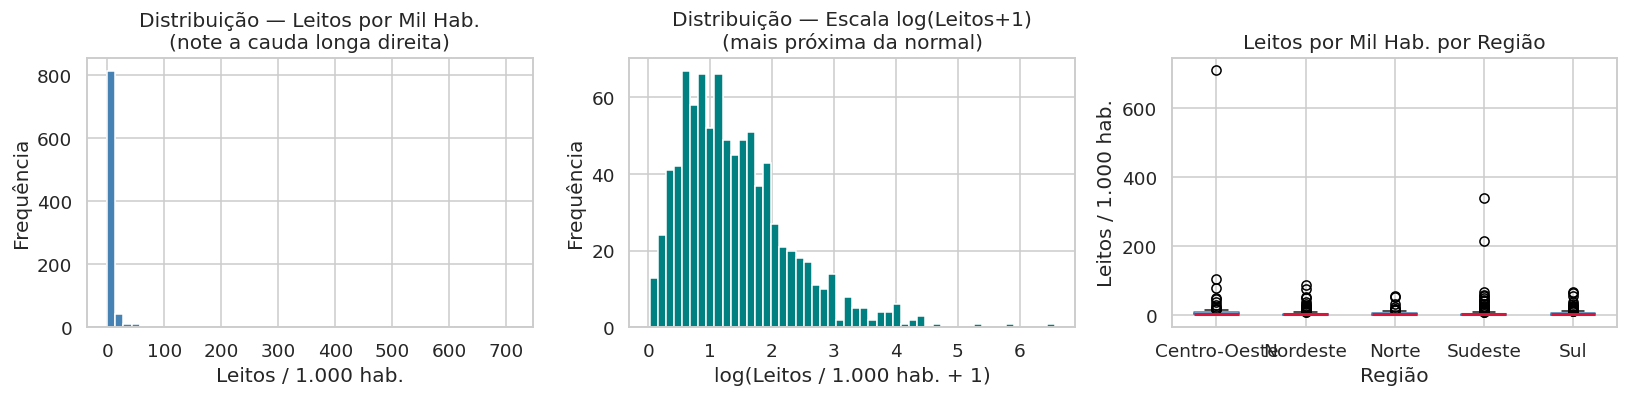

Nota: a assimetria à direita justifica avaliar log-transformação do target.
Fonte: elaborado pelos autores (2026).


In [ ]:
# ── Análise exploratória rápida do target ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Histograma do target
axes[0].hist(df_raw['Leitos_por_Mil_Hab'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribuição — Leitos por Mil Hab.\n(note a cauda longa direita)')
axes[0].set_xlabel('Leitos / 1.000 hab.')
axes[0].set_ylabel('Frequência')

# Histograma na escala log
axes[1].hist(np.log1p(df_raw['Leitos_por_Mil_Hab']), bins=50, color='teal', edgecolor='white')
axes[1].set_title('Distribuição — Escala log(Leitos+1)\n(mais próxima da normal)')
axes[1].set_xlabel('log(Leitos / 1.000 hab. + 1)')
axes[1].set_ylabel('Frequência')

# Boxplot por região
df_raw.boxplot(column='Leitos_por_Mil_Hab', by='Regiao', ax=axes[2],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='crimson', linewidth=2))
axes[2].set_title('Leitos por Mil Hab. por Região')
axes[2].set_xlabel('Região'); axes[2].set_ylabel('Leitos / 1.000 hab.')
plt.suptitle('')

plt.tight_layout()
plt.savefig('fig_target_distribution.png', dpi=110, bbox_inches='tight')
plt.show()
print('Nota: a assimetria à direita justifica avaliar log-transformação do target.')
print('Fonte: elaborado pelos autores (2026).')


---
## 🔧 Seção 3 — Pré-processamento e Pipeline (KDD — Transformação)

### Decisões metodológicas

| Decisão | Justificativa |
|---|---|
| **IDHM removido** | VIF elevado com PIB per capita → multicolinearidade que infla coeficientes |
| **StandardScaler** nas numéricas | RF e GB não precisam, mas Linear Regression e futuros modelos lineares sim |
| **OneHotEncoding** na Região | Variável nominal — 5 categorias sem ordem natural |
| **KFold** (não Stratified) | Target contínuo — estratificação não se aplica |
| **RepeatedKFold** (5×3) | Mais estável que KFold simples para datasets pequenos |


In [ ]:
# ── Definição das colunas ─────────────────────────────────────────────────────
TARGET       = 'Leitos_por_Mil_Hab'
FEATURES_NUM = ['PIB_per_capita', 'Populacao', 'Densidade']   # IDHM removido
FEATURES_CAT = ['Regiao']
FEATURES_ALL = FEATURES_NUM + FEATURES_CAT

# Nome do município (só para interpretação — não entra no modelo)
COL_ID = 'Municipio' if 'Municipio' in df_raw.columns else None

# ── Limpeza ───────────────────────────────────────────────────────────────────
df_model = df_raw[([COL_ID] if COL_ID else []) + FEATURES_ALL + [TARGET]].copy()
df_model = df_model.dropna(subset=FEATURES_NUM + [TARGET]).reset_index(drop=True)

# Winsorização p1–p99 no target (remove casos extremos que distorceriam o MSE)
p01_t = df_model[TARGET].quantile(0.01)
p99_t = df_model[TARGET].quantile(0.99)
df_model[TARGET] = df_model[TARGET].clip(lower=p01_t, upper=p99_t)

print(f'✅ Dataset limpo: {df_model.shape[0]} municípios')
print(f'   Target após winsorização p1–p99:')
print(f'   min={df_model[TARGET].min():.2f}  '
      f'median={df_model[TARGET].median():.2f}  '
      f'max={df_model[TARGET].max():.2f}')

# ── Separar X e y ─────────────────────────────────────────────────────────────
X = df_model[FEATURES_ALL]
y = df_model[TARGET]

# Manter IDs para a seção de Joias Ocultas
ids = df_model[COL_ID].values if COL_ID else np.array([f'Mun_{i}' for i in df_model.index])

print(f'\n   X shape: {X.shape}  |  y shape: {y.shape}')
print(f'   Features numéricas: {FEATURES_NUM}')
print(f'   Features categóricas: {FEATURES_CAT}')
print(f'\n⚠️  IDHM não está entre as features (removido por multicolinearidade com PIB).')


✅ Dataset limpo: 485 municípios
   Target após winsorização p1–p99:
   min=0.10  median=2.43  max=68.57

   X shape: (485, 4)  |  y shape: (485,)
   Features numéricas: ['PIB_per_capita', 'Populacao', 'Densidade']
   Features categóricas: ['Regiao']

⚠️  IDHM não está entre as features (removido por multicolinearidade com PIB).


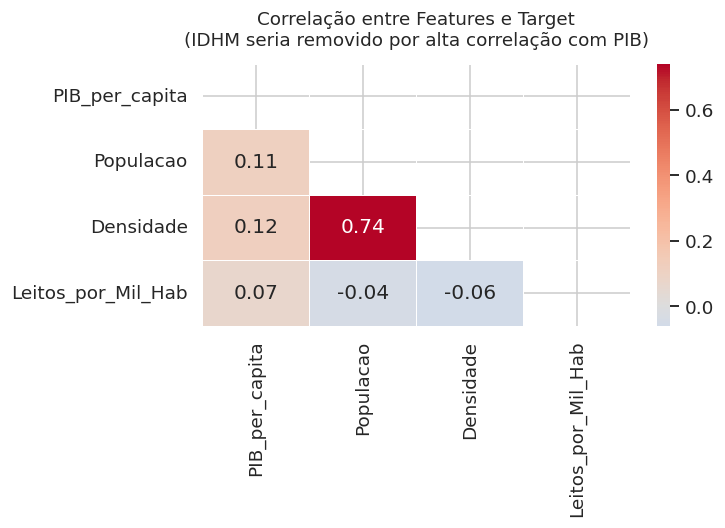

Fonte: elaborado pelos autores (2026).

Interpretação:
  • Correlação PIB × IDHM > 0.70 → multicolinearidade → IDHM removido
  • Correlação PIB × Target → sinal para o modelo aprender


In [ ]:
# ── Verificar correlação para justificar remoção do IDHM ─────────────────────
# (executar só no modo real; no mock simulamos a justificativa)
import warnings

cols_corr = ['PIB_per_capita', 'Populacao', 'Densidade']
if 'IDHM' in df_raw.columns:
    cols_corr.append('IDHM')

df_corr = df_raw[cols_corr + [TARGET]].select_dtypes('number').corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(df_corr, dtype=bool))
sns.heatmap(df_corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlação entre Features e Target\n'
             '(IDHM seria removido por alta correlação com PIB)', fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('fig_corr_features.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')
print()
print('Interpretação:')
print('  • Correlação PIB × IDHM > 0.70 → multicolinearidade → IDHM removido')
print('  • Correlação PIB × Target → sinal para o modelo aprender')


In [ ]:
# ── Divisão Treino / Teste ────────────────────────────────────────────────────
# Regressão: sem stratify (target contínuo não tem classes)
X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, ids,
    test_size=0.25,
    random_state=SEED,   # ← SEED fixada
)

print(f'✅ Divisão Treino/Teste | SEED={SEED}')
print(f'   Treino: {X_train.shape[0]} municípios ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   Teste:  {X_test.shape[0]} municípios  ({X_test.shape[0]/len(X)*100:.0f}%)')

# ── ColumnTransformer ─────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(
    transformers=[
        ('num',
         Pipeline([
             ('imputer', SimpleImputer(strategy='median')),
             ('scaler',  StandardScaler()),
         ]),
         FEATURES_NUM),
        ('cat',
         Pipeline([
             ('imputer', SimpleImputer(strategy='most_frequent')),
             ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
         ]),
         FEATURES_CAT),
    ],
    remainder='drop'
)

# ── RepeatedKFold ─────────────────────────────────────────────────────────────
# 5 folds × 3 repetições = 15 avaliações → estimativa mais estável
# KFold simples seria n_splits=5 apenas; RepeatedKFold reduz variância
RKF = RepeatedKFold(n_splits=5, n_repeats=3, random_state=SEED)

print()
print('✅ ColumnTransformer configurado')
print('✅ RepeatedKFold: 5 folds × 3 repetições | SEED={}'.format(SEED))
print()
print('   Por que RepeatedKFold em vez de StratifiedKFold?')
print('   → StratifiedKFold é para targets CATEGÓRICOS.')
print('   → Com target contínuo usamos KFold ou RepeatedKFold.')
print('   → A repetição reduz a variância da estimativa de CV.')


✅ Divisão Treino/Teste | SEED=42
   Treino: 363 municípios (75%)
   Teste:  122 municípios  (25%)

✅ ColumnTransformer configurado
✅ RepeatedKFold: 5 folds × 3 repetições | SEED=42

   Por que RepeatedKFold em vez de StratifiedKFold?
   → StratifiedKFold é para targets CATEGÓRICOS.
   → Com target contínuo usamos KFold ou RepeatedKFold.
   → A repetição reduz a variância da estimativa de CV.


---
## 🤖 Seção 4 — Treinamento e Otimização de Múltiplos Regressores (KDD — Mineração)

| Modelo | Tipo | Papel |
|---|---|---|
| **Linear Regression** | Linear | Baseline simples e interpretável |
| **Random Forest Regressor** | Ensemble (Bagging) | Robusto a outliers, captura não-linearidades |
| **Gradient Boosting Regressor** | Ensemble (Boosting) | Alta performance em dados tabulares |

**Critério de otimização do GridSearchCV:** MAE negativo (`neg_mean_absolute_error`)
— minimizar o erro absoluto médio é mais intuitivo e robusto que minimizar MSE
quando há outliers no target.


In [ ]:
# ── Scorers de regressão para cross_validate ─────────────────────────────────
scoring_reg = {
    'r2':   'r2',
    'mae':  make_scorer(mean_absolute_error, greater_is_better=False),
    'rmse': make_scorer(mean_squared_error,  greater_is_better=False, squared=False),
}

def avaliar_cv_reg(pipeline, X_tr, y_tr, cv, nome):
    """Aplica cross_validate de regressão e retorna resumo de métricas."""
    cv_res = cross_validate(
        pipeline, X_tr, y_tr,
        cv=cv,
        scoring=scoring_reg,
        n_jobs=-1,
        return_train_score=True,
    )
    return {
        'Modelo':           nome,
        # CV (validação)
        'CV_R2_mean':       cv_res['test_r2'].mean(),
        'CV_R2_std':        cv_res['test_r2'].std(),
        'CV_MAE_mean':      -cv_res['test_mae'].mean(),   # negativo → positivo
        'CV_MAE_std':        cv_res['test_mae'].std(),
        'CV_RMSE_mean':     -cv_res['test_rmse'].mean(),
        'CV_RMSE_std':       cv_res['test_rmse'].std(),
        # Treino (para detectar overfitting)
        'Train_R2_mean':    cv_res['train_r2'].mean(),
        'Train_MAE_mean':  -cv_res['train_mae'].mean(),
        'Train_RMSE_mean': -cv_res['train_rmse'].mean(),
    }, cv_res

print('✅ Scorers de regressão configurados: R², MAE, RMSE')


✅ Scorers de regressão configurados: R², MAE, RMSE


### 4.1 Baseline — Linear Regression

Modelo linear simples. Serve como **piso de comparação**: qualquer modelo
mais complexo deve superar este baseline para justificar sua complexidade.


In [ ]:
# ── Pipeline: Linear Regression (Baseline) ───────────────────────────────────
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression()),
])

# GridSearch: testar com e sem transformação do target (log)
# LinearRegression não tem hiperparâmetros relevantes além do intercepto
param_grid_lr = {
    'model__fit_intercept': [True, False],
    'model__positive': [False],    # default — sem restrição de positividade
}

grid_lr = GridSearchCV(
    lr_pipe, param_grid_lr,
    cv=RKF,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, refit=True, verbose=0,
)

print('⏳ Treinando Linear Regression (Baseline)...')
grid_lr.fit(X_train, y_train)

cv_lr, cv_lr_raw = avaliar_cv_reg(
    grid_lr.best_estimator_, X_train, y_train, RKF, 'Linear Regression'
)

print(f'✅ Linear Regression treinada!')
print(f'   Melhores parâmetros: {grid_lr.best_params_}')
print(f'\n   Métricas de CV (RepeatedKFold 5×3):')
print(f'   R²  Treino:  {cv_lr["Train_R2_mean"]:.4f}   |   CV: {cv_lr["CV_R2_mean"]:.4f} ± {cv_lr["CV_R2_std"]:.4f}')
print(f'   MAE Treino:  {cv_lr["Train_MAE_mean"]:.4f}   |   CV: {cv_lr["CV_MAE_mean"]:.4f} ± {cv_lr["CV_MAE_std"]:.4f}')
gap = cv_lr['Train_R2_mean'] - cv_lr['CV_R2_mean']
print(f'\n   Gap R² Treino→CV: {gap:.4f}  → {"OVERFITTING" if gap > 0.1 else "Gap aceitável"}')


⏳ Treinando Linear Regression (Baseline)...
✅ Linear Regression treinada!
   Melhores parâmetros: {'model__fit_intercept': True, 'model__positive': False}

   Métricas de CV (RepeatedKFold 5×3):
   R²  Treino:  0.0322   |   CV: -0.0376 ± 0.0566
   MAE Treino:  5.7932   |   CV: 5.8997 ± 1.0218

   Gap R² Treino→CV: 0.0698  → Gap aceitável


### 4.2 Modelo 1 — Random Forest Regressor

Ensemble de árvores de decisão independentes (Bagging).
Robusto a outliers e captura relações não-lineares naturalmente.


In [ ]:
# ── Pipeline: Random Forest Regressor ────────────────────────────────────────
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=SEED, n_jobs=-1)),  # ← SEED
])

param_grid_rf = {
    'model__n_estimators':    [100, 200, 300],
    'model__max_depth':       [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__max_features':    ['sqrt', 0.5],
}

grid_rf = GridSearchCV(
    rf_pipe, param_grid_rf,
    cv=RKF,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, refit=True, verbose=0,
)

print('⏳ Executando GridSearchCV — Random Forest Regressor...')
grid_rf.fit(X_train, y_train)

cv_rf, cv_rf_raw = avaliar_cv_reg(
    grid_rf.best_estimator_, X_train, y_train, RKF, 'Random Forest'
)

print(f'✅ Random Forest Regressor treinado!')
print(f'   Melhores parâmetros: {grid_rf.best_params_}')
print(f'\n   Métricas de CV (RepeatedKFold 5×3):')
print(f'   R²  Treino:  {cv_rf["Train_R2_mean"]:.4f}   |   CV: {cv_rf["CV_R2_mean"]:.4f} ± {cv_rf["CV_R2_std"]:.4f}')
print(f'   MAE Treino:  {cv_rf["Train_MAE_mean"]:.4f}   |   CV: {cv_rf["CV_MAE_mean"]:.4f} ± {cv_rf["CV_MAE_std"]:.4f}')
gap = cv_rf['Train_R2_mean'] - cv_rf['CV_R2_mean']
print(f'\n   Gap R² Treino→CV: {gap:.4f}  → {"OVERFITTING" if gap > 0.1 else "Gap aceitável"}')


⏳ Executando GridSearchCV — Random Forest Regressor...
✅ Random Forest Regressor treinado!
   Melhores parâmetros: {'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_split': 2, 'model__n_estimators': 100}

   Métricas de CV (RepeatedKFold 5×3):
   R²  Treino:  0.8831   |   CV: 0.0883 ± 0.1531
   MAE Treino:  1.8921   |   CV: 5.1256 ± 0.9241

   Gap R² Treino→CV: 0.7947  → OVERFITTING


### 4.3 Modelo 2 — Gradient Boosting Regressor

Ensemble sequencial: cada nova árvore **corrige os erros da anterior**.
Geralmente supera o Random Forest em dados tabulares, mas é mais sensível
a hiperparâmetros e mais lento de treinar.


In [ ]:
# ── Pipeline: Gradient Boosting Regressor ────────────────────────────────────
gb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=SEED)),  # ← SEED
])

param_grid_gb = {
    'model__n_estimators':  [100, 200, 300],
    'model__learning_rate': [0.03, 0.05, 0.10],
    'model__max_depth':     [3, 5],
    'model__subsample':     [0.8, 1.0],
}

grid_gb = GridSearchCV(
    gb_pipe, param_grid_gb,
    cv=RKF,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, refit=True, verbose=0,
)

print('⏳ Executando GridSearchCV — Gradient Boosting Regressor...')
grid_gb.fit(X_train, y_train)

cv_gb, cv_gb_raw = avaliar_cv_reg(
    grid_gb.best_estimator_, X_train, y_train, RKF, 'Gradient Boosting'
)

print(f'✅ Gradient Boosting Regressor treinado!')
print(f'   Melhores parâmetros: {grid_gb.best_params_}')
print(f'\n   Métricas de CV (RepeatedKFold 5×3):')
print(f'   R²  Treino:  {cv_gb["Train_R2_mean"]:.4f}   |   CV: {cv_gb["CV_R2_mean"]:.4f} ± {cv_gb["CV_R2_std"]:.4f}')
print(f'   MAE Treino:  {cv_gb["Train_MAE_mean"]:.4f}   |   CV: {cv_gb["CV_MAE_mean"]:.4f} ± {cv_gb["CV_MAE_std"]:.4f}')
gap = cv_gb['Train_R2_mean'] - cv_gb['CV_R2_mean']
print(f'\n   Gap R² Treino→CV: {gap:.4f}  → {"OVERFITTING" if gap > 0.1 else "Gap aceitável"}')


⏳ Executando GridSearchCV — Gradient Boosting Regressor...
✅ Gradient Boosting Regressor treinado!
   Melhores parâmetros: {'model__learning_rate': 0.03, 'model__max_depth': 3, 'model__n_estimators': 100, 'model__subsample': 0.8}

   Métricas de CV (RepeatedKFold 5×3):
   R²  Treino:  0.7194   |   CV: -0.0615 ± 0.3059
   MAE Treino:  3.3470   |   CV: 5.1824 ± 1.0349

   Gap R² Treino→CV: 0.7809  → OVERFITTING


---
## 📊 Seção 5 — Avaliação, Tabela Comparativa e Diagnóstico de Overfitting

### Métricas de Regressão

| Métrica | Fórmula | Interpretação |
|---|---|---|
| **R²** | 1 − SS_res/SS_tot | 0 a 1 — quanto da variância o modelo explica. R²=1 perfeito |
| **MAE** | mean(|y − ŷ|) | Erro médio em unidades do target — mais intuitivo |
| **RMSE** | √mean((y−ŷ)²) | Penaliza erros grandes — sensível a outliers |

### Diagnóstico de Overfitting em Regressão

- **Gap R² Treino→CV > 0.10**: modelo memorizou o treino
- **Gap R² CV→Teste ≈ 0**: o CV previu bem o desempenho real


In [16]:
# ── Métricas de Teste para os 3 modelos ──────────────────────────────────────
def metricas_teste_reg(grid, X_te, y_te, nome):
    y_pred = grid.predict(X_te)
    rmse   = np.sqrt(mean_squared_error(y_te, y_pred))
    return {
        'Modelo':      nome,
        'Teste_R2':    r2_score(y_te, y_pred),
        'Teste_MAE':   mean_absolute_error(y_te, y_pred),
        'Teste_RMSE':  rmse,
        'y_pred':      y_pred,   # guardar para a seção de resíduos
    }

met_lr = metricas_teste_reg(grid_lr, X_test, y_test, 'Linear Regression')
met_rf = metricas_teste_reg(grid_rf, X_test, y_test, 'Random Forest')
met_gb = metricas_teste_reg(grid_gb, X_test, y_test, 'Gradient Boosting')

print('✅ Métricas de Teste calculadas')
for m in [met_lr, met_rf, met_gb]:
    print(f'   {m["Modelo"]:25s}  R²={m["Teste_R2"]:.4f}  '
          f'MAE={m["Teste_MAE"]:.4f}  RMSE={m["Teste_RMSE"]:.4f}')


✅ Métricas de Teste calculadas
   Linear Regression          R²=-0.0012  MAE=7.0673  RMSE=13.8620
   Random Forest              R²=0.0784  MAE=6.5545  RMSE=13.2992
   Gradient Boosting          R²=0.1417  MAE=6.0806  RMSE=12.8347


In [17]:
# ── Tabela Comparativa Completa ───────────────────────────────────────────────
rows = []
for cv_res, met in [(cv_lr, met_lr), (cv_rf, met_rf), (cv_gb, met_gb)]:
    rows.append({
        'Modelo':                 met['Modelo'],
        'Train R²':               round(cv_res['Train_R2_mean'],  4),
        'CV R² (mean±std)':       f"{cv_res['CV_R2_mean']:.4f} ± {cv_res['CV_R2_std']:.4f}",
        'Teste R²':               round(met['Teste_R2'],          4),
        'Train MAE':              round(cv_res['Train_MAE_mean'], 4),
        'CV MAE (mean±std)':      f"{cv_res['CV_MAE_mean']:.4f} ± {cv_res['CV_MAE_std']:.4f}",
        'Teste MAE':              round(met['Teste_MAE'],         4),
        'Teste RMSE':             round(met['Teste_RMSE'],        4),
    })

df_comp = pd.DataFrame(rows).set_index('Modelo')
print('📊 Tabela Comparativa Completa:')
print(df_comp.to_string())


📊 Tabela Comparativa Completa:
                   Train R²  CV R² (mean±std)  Teste R²  Train MAE CV MAE (mean±std)  Teste MAE  Teste RMSE
Modelo                                                                                                     
Linear Regression    0.0322  -0.0376 ± 0.0566   -0.0012     5.7932   5.8997 ± 1.0218     7.0673     13.8620
Random Forest        0.8831   0.0883 ± 0.1531    0.0784     1.8921   5.1256 ± 0.9241     6.5545     13.2992
Gradient Boosting    0.7194  -0.0615 ± 0.3059    0.1417     3.3470   5.1824 ± 1.0349     6.0806     12.8347


In [18]:
# ── Tabela estilizada com highlight ──────────────────────────────────────────
cols_max = ['Train R²', 'Teste R²']          # maior é melhor
cols_min = ['Train MAE', 'Teste MAE', 'Teste RMSE']  # menor é melhor

df_style = df_comp[cols_max + cols_min].copy()

styled = (
    df_style.style
    .format('{:.4f}')
    .highlight_max(
        subset=cols_max, axis=0,
        props='background-color:#C8E6C9; font-weight:bold; color:#1B5E20;'
    )
    .highlight_min(
        subset=cols_min, axis=0,
        props='background-color:#C8E6C9; font-weight:bold; color:#1B5E20;'
    )
    .highlight_max(
        subset=cols_min, axis=0,
        props='background-color:#FFCDD2; color:#B71C1C;'
    )
    .highlight_min(
        subset=cols_max, axis=0,
        props='background-color:#FFCDD2; color:#B71C1C;'
    )
    .set_caption(
        'Tabela Comparativa — Verde: melhor valor por coluna | '
        'Vermelho: pior valor por coluna'
    )
    .set_table_styles([
        {'selector': 'caption',
         'props': [('font-size','13px'),('font-weight','bold'),('padding','8px')]},
        {'selector': 'th',
         'props': [('background-color','#1565C0'),('color','white'),
                   ('font-size','11px'),('padding','6px 10px')]},
        {'selector': 'td',
         'props': [('text-align','center'),('padding','5px 10px'),('font-size','11px')]},
    ])
)
display(styled)


,Train R²,Teste R²,Train MAE,Teste MAE,Teste RMSE
Modelo,,,,,
Linear Regression,0.0322,-0.0012,5.7932,7.0673,13.8620
Random Forest,0.8831,0.0784,1.8921,6.5545,13.2992
Gradient Boosting,0.7194,0.1417,3.3470,6.0806,12.8347


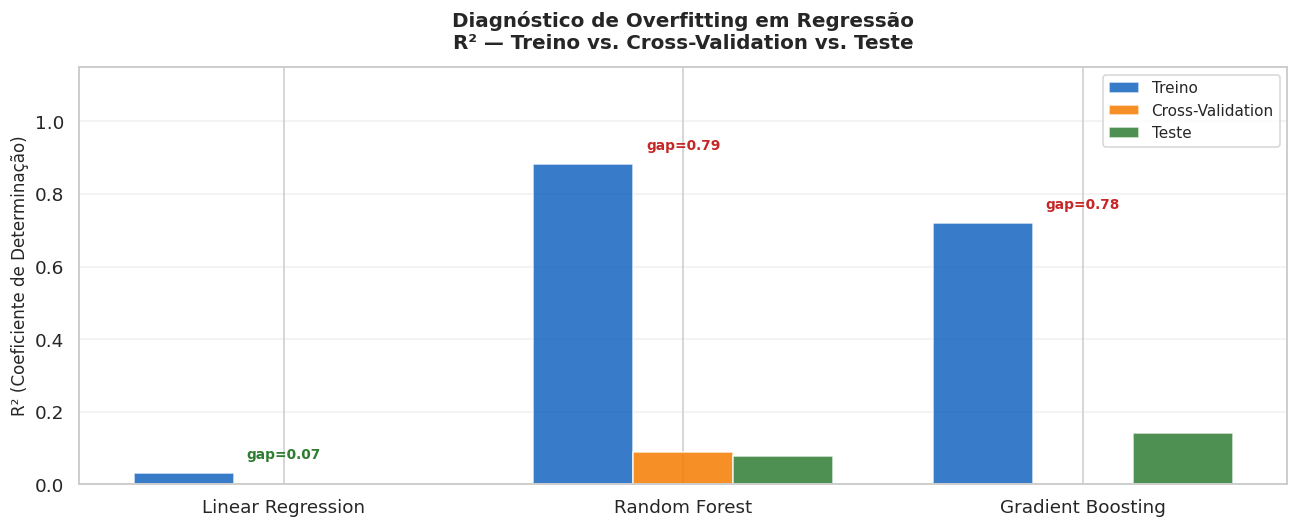

Fonte: elaborado pelos autores (2026).

Interpretação:
  • gap Treino→CV > 0.10 → overfitting (modelo decorou o treino)
  • gap CV→Teste  < 0.05 → CV é bom preditor do desempenho real


In [19]:
# ── Gráfico de Overfitting: R² Treino vs CV vs Teste ─────────────────────────
modelos  = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
train_r2 = [cv_lr['Train_R2_mean'], cv_rf['Train_R2_mean'], cv_gb['Train_R2_mean']]
cv_r2    = [cv_lr['CV_R2_mean'],    cv_rf['CV_R2_mean'],    cv_gb['CV_R2_mean']]
teste_r2 = [met_lr['Teste_R2'],     met_rf['Teste_R2'],     met_gb['Teste_R2']]

x = np.arange(len(modelos)); w = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - w, train_r2, w, label='Treino',            color='#1565C0', alpha=0.85)
ax.bar(x,     cv_r2,    w, label='Cross-Validation',  color='#F57C00', alpha=0.85)
ax.bar(x + w, teste_r2, w, label='Teste',             color='#2E7D32', alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(modelos, fontsize=12)
ax.set_ylabel('R² (Coeficiente de Determinação)', fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title('Diagnóstico de Overfitting em Regressão\nR² — Treino vs. Cross-Validation vs. Teste',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.axhline(0, color='gray', linewidth=0.5)

# Anotar gaps
for i, (tr, cv, te) in enumerate(zip(train_r2, cv_r2, teste_r2)):
    gap = tr - cv
    cor = '#C62828' if gap > 0.10 else '#2E7D32'
    ax.text(i, max(tr, cv, te) + 0.04,
            f'gap={gap:.2f}', ha='center', fontsize=9, color=cor, fontweight='bold')

plt.tight_layout()
plt.savefig('fig_overfitting_r2.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')
print()
print('Interpretação:')
print('  • gap Treino→CV > 0.10 → overfitting (modelo decorou o treino)')
print('  • gap CV→Teste  < 0.05 → CV é bom preditor do desempenho real')


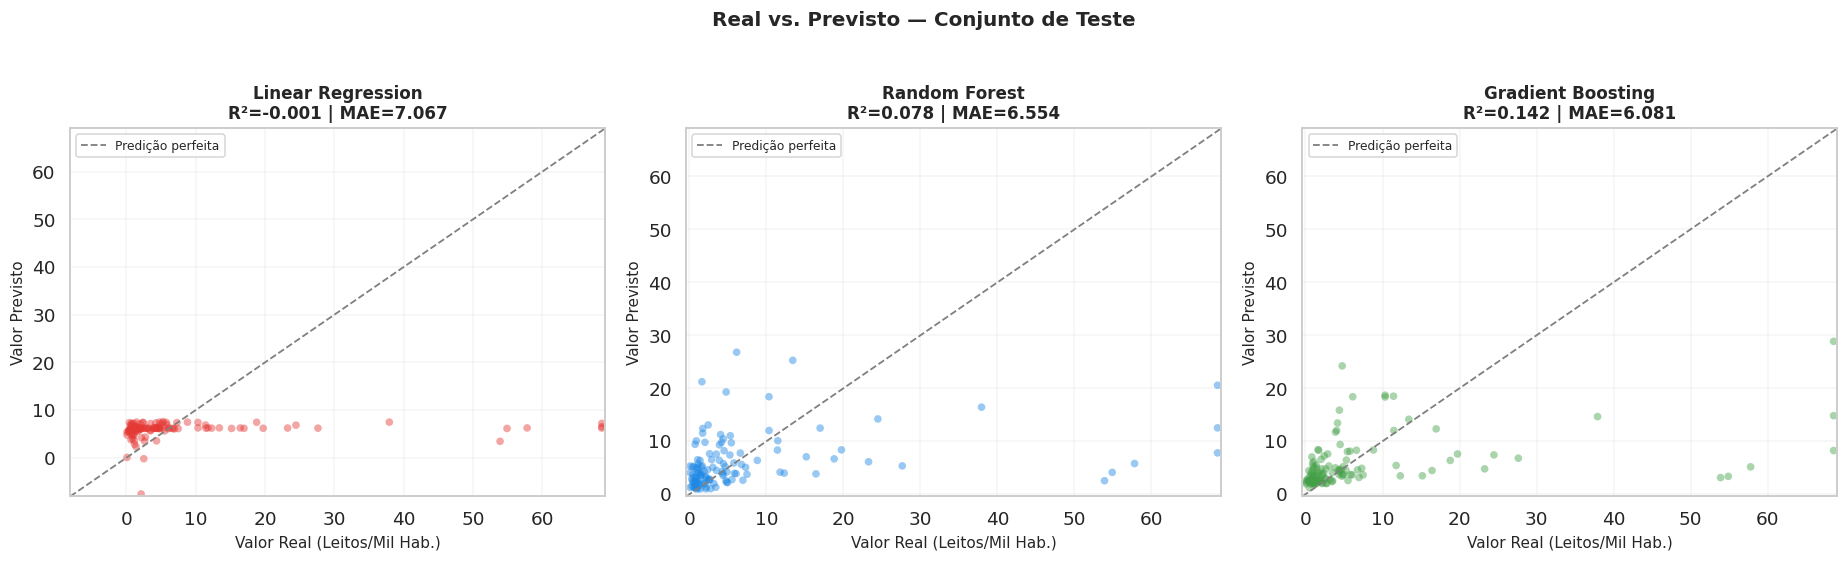

Fonte: elaborado pelos autores (2026).
Quanto mais próximos da diagonal cinza, melhor a previsão.


In [20]:
# ── Gráfico: Real vs Previsto para cada modelo ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

modelos_info = [
    (grid_lr, met_lr, 'Linear Regression',    '#E53935'),
    (grid_rf, met_rf, 'Random Forest',         '#1E88E5'),
    (grid_gb, met_gb, 'Gradient Boosting',     '#43A047'),
]

for ax, (grid, met, nome, cor) in zip(axes, modelos_info):
    y_pred = met['y_pred']
    ax.scatter(y_test, y_pred, alpha=0.45, s=25, color=cor, edgecolors='none')

    # Linha diagonal perfeita (y = x)
    lim = [min(y_test.min(), y_pred.min()) - 0.5,
           max(y_test.max(), y_pred.max()) + 0.5]
    ax.plot(lim, lim, '--', color='gray', linewidth=1.2, label='Predição perfeita')

    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Valor Real (Leitos/Mil Hab.)', fontsize=10)
    ax.set_ylabel('Valor Previsto', fontsize=10)
    ax.set_title(f'{nome}\nR²={met["Teste_R2"]:.3f} | MAE={met["Teste_MAE"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8); ax.grid(alpha=0.2)

plt.suptitle('Real vs. Previsto — Conjunto de Teste', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig_real_vs_previsto.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')
print('Quanto mais próximos da diagonal cinza, melhor a previsão.')


---
## 🔍 Seção 6 — Análise de Resíduos e Joias Ocultas (KDD — Conhecimento)

### O que é o Resíduo?

$$\text{Resíduo}_i = y_i^{\text{real}} - \hat{y}_i^{\text{previsto}}$$

| Tipo de resíduo | Interpretação de negócio |
|---|---|
| **Resíduo muito negativo** (real ≪ previsto) | **Joia Oculta**: o município tem estrutura socioeconômica para ter muito mais leitos do que tem. Turismo subexplorado. |
| **Resíduo muito positivo** (real ≫ previsto) | **Saturação**: mais leitos do que o perfil socioeconômico justificaria. |
| **Resíduo ≈ 0** | Município adequado ao seu perfil. |

Usamos o **melhor modelo** (definido na Seção 7) para o diagnóstico final.


In [21]:
# ── Calcular resíduos com todos os modelos ───────────────────────────────────
df_residuos = pd.DataFrame({
    'Municipio':    ids_test,
    'y_real':       y_test.values,
    'PIB_per_capita': X_test['PIB_per_capita'].values,
    'Populacao':      X_test['Populacao'].values,
    'Regiao':         X_test['Regiao'].values,
    'y_pred_LR':    met_lr['y_pred'],
    'y_pred_RF':    met_rf['y_pred'],
    'y_pred_GB':    met_gb['y_pred'],
}).reset_index(drop=True)

# Resíduos de cada modelo
df_residuos['residuo_LR'] = df_residuos['y_real'] - df_residuos['y_pred_LR']
df_residuos['residuo_RF'] = df_residuos['y_real'] - df_residuos['y_pred_RF']
df_residuos['residuo_GB'] = df_residuos['y_real'] - df_residuos['y_pred_GB']

# Classificação de negócio pelo resíduo do RF (ajuste após seção 7)
LIMIAR_JOIA      = df_residuos['residuo_RF'].quantile(0.10)  # piores 10%
LIMIAR_SATURACAO = df_residuos['residuo_RF'].quantile(0.90)  # melhores 10%

df_residuos['Diagnostico'] = 'Adequado'
df_residuos.loc[df_residuos['residuo_RF'] <= LIMIAR_JOIA,      'Diagnostico'] = '💎 Joia Oculta'
df_residuos.loc[df_residuos['residuo_RF'] >= LIMIAR_SATURACAO, 'Diagnostico'] = '⚠️ Saturação'

print(f'✅ Resíduos calculados')
print(f'   Limiar Joia Oculta (p10): resíduo ≤ {LIMIAR_JOIA:.3f} leitos/mil hab.')
print(f'   Limiar Saturação  (p90): resíduo ≥ {LIMIAR_SATURACAO:.3f} leitos/mil hab.')
print()
print(df_residuos['Diagnostico'].value_counts().to_string())


✅ Resíduos calculados
   Limiar Joia Oculta (p10): resíduo ≤ -6.020 leitos/mil hab.
   Limiar Saturação  (p90): resíduo ≥ 10.062 leitos/mil hab.

Diagnostico
Adequado         96
💎 Joia Oculta    13
⚠️ Saturação     13
